
# Exploration approfondie des données Adzuna

Ce notebook propose une exploration **plus complète, structurée et utile** du dataset Adzuna.

Objectifs :
- comprendre précisément **toutes les colonnes** ;
- mesurer la **qualité des données** (nulls, doublons, formats, valeurs rares) ;
- analyser les colonnes texte, dates, salaires et catégories ;
- produire une **lecture métier** des données avant nettoyage / stockage.


In [1]:

import sys
import os
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from scripts.ingestion.adzuna_client import collect_adzuna, filter_new_jobs

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

raw_jobs = collect_adzuna(max_days_old=5)
last_run = (datetime.now() - timedelta(hours=48)).strftime('%Y-%m-%dT%H:%M:%SZ')
new_jobs = filter_new_jobs(raw_jobs, last_run)

df = pd.DataFrame(raw_jobs)

print(f"Total jobs: {len(raw_jobs)}")
print(f"New jobs since last run: {len(new_jobs)}")
print(f"Rows in DataFrame: {df.shape[0]}")
print(f"Columns in DataFrame: {df.shape[1]}")


2026-04-23 15:38:28,501 | INFO | adzuna_client | Adzuna ingestion started
2026-04-23 15:38:28,503 | INFO | adzuna_client | Fetching Adzuna page 1
2026-04-23 15:38:31,766 | INFO | adzuna_client | Fetching Adzuna page 2
2026-04-23 15:38:34,722 | INFO | adzuna_client | Fetching Adzuna page 3
2026-04-23 15:38:37,809 | INFO | adzuna_client | Fetching Adzuna page 4
2026-04-23 15:38:40,839 | INFO | adzuna_client | Fetching Adzuna page 5
2026-04-23 15:38:43,898 | INFO | adzuna_client | Fetching Adzuna page 6
2026-04-23 15:38:46,972 | INFO | adzuna_client | Fetching Adzuna page 7
2026-04-23 15:38:50,070 | INFO | adzuna_client | Fetching Adzuna page 8
2026-04-23 15:38:53,253 | INFO | adzuna_client | Fetching Adzuna page 9
2026-04-23 15:38:56,217 | INFO | adzuna_client | Fetching Adzuna page 10
2026-04-23 15:38:59,252 | INFO | adzuna_client | Adzuna collected 500 jobs
2026-04-23 15:38:59,298 | INFO | adzuna_client | Adzuna filtered 222 new jobs
Total jobs: 500
New jobs since last run: 222
Rows in

## 1. Vue générale du dataset

In [3]:

display(df.head(3))
print("Colonnes :")
print(df.columns.tolist())


,id,title,description,salary_min,salary_max,created,contract_time,contract_type,redirect_url,company,location,category
0,5706251377,Alternant Data sales analyst ( ),Description du poste Bienvenue ! Cette opportunité fait partie d’un programme d'alternance proposé par OpenClassroom...,108000.0,192000.0,2026-04-21T18:23:28Z,full_time,contract,https://www.adzuna.fr/land/ad/5706251377?se=eLsIGiI_8RG_zfuIgPGcmA&utm_medium=api&utm_source=e5976890&v=D09233DBBA65...,"{'display_name': 'OpenClassrooms', '__CLASS__': 'Adzuna::API::Response::Company'}","{'area': ['France', 'Normandie', 'Seine-Maritime', 'Rouen', 'Yerville'], 'display_name': 'Yerville, Rouen', '__CLASS...","{'label': 'Emplois Autres/Général', '__CLASS__': 'Adzuna::API::Response::Category', 'tag': 'other-general-jobs'}"
1,5706251383,Alternant Data sales analyst ( ),Description du poste Bienvenue ! Cette opportunité fait partie d’un programme d'alternance proposé par OpenClassroom...,108000.0,192000.0,2026-04-21T18:23:28Z,full_time,contract,https://www.adzuna.fr/land/ad/5706251383?se=eLsIGiI_8RG_zfuIgPGcmA&utm_medium=api&utm_source=e5976890&v=E74CFD7D33BE...,"{'__CLASS__': 'Adzuna::API::Response::Company', 'display_name': 'OpenClassrooms'}","{'display_name': 'Seine-Maritime, Normandie', '__CLASS__': 'Adzuna::API::Response::Location', 'area': ['France', 'No...","{'label': 'Emplois Autres/Général', 'tag': 'other-general-jobs', '__CLASS__': 'Adzuna::API::Response::Category'}"
2,5706525868,Data Engineer H/F (CDI),Notre client est une organisation à but non lucratif reconnue pour son engagement dans le fait de prodiguer des soin...,NaN,NaN,2026-04-21T23:32:39Z,NaN,permanent,https://www.adzuna.fr/land/ad/5706525868?se=eLsIGiI_8RG_zfuIgPGcmA&utm_medium=api&utm_source=e5976890&v=0AD14542511B...,"{'display_name': 'Michael Page', '__CLASS__': 'Adzuna::API::Response::Company'}","{'display_name': 'Sèvres, Boulogne-Billancourt', '__CLASS__': 'Adzuna::API::Response::Location', 'area': ['France', ...","{'label': 'Unknown', 'tag': 'unknown', '__CLASS__': 'Adzuna::API::Response::Category'}"


Colonnes :
['id', 'title', 'description', 'salary_min', 'salary_max', 'created', 'contract_time', 'contract_type', 'redirect_url', 'company', 'location', 'category']


In [5]:
overview = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'non_null_count': [df[c].notna().sum() for c in df.columns],
    'null_count': [df[c].isna().sum() for c in df.columns],
    'null_pct': [round(df[c].isna().mean()*100, 2) for c in df.columns],
    'unique_count': [
        df[c].dropna().astype(str).nunique()
        for c in df.columns
    ],
    'sample_values': [
        ', '.join(df[c].dropna().astype(str).head(3).tolist())
        for c in df.columns
    ]
}).sort_values(['null_pct', 'unique_count'], ascending=[False, False])

display(overview)

,column,dtype,non_null_count,null_count,null_pct,unique_count,sample_values
4,salary_max,float64,141,359,71.8,51,"192000.0, 192000.0, 20000.0"
3,salary_min,float64,143,357,71.4,50,"108000.0, 108000.0, 20000.0"
6,contract_time,object,179,321,64.2,2,"full_time, full_time, full_time"
7,contract_type,object,250,250,50.0,2,"contract, contract, permanent"
0,id,object,500,0,0.0,500,"5706251377, 5706251383, 5706525868"
8,redirect_url,object,500,0,0.0,500,https://www.adzuna.fr/land/ad/5706251377?se=eLsIGiI_8RG_zfuIgPGcmA&utm_medium=api&utm_source=e5976890&v=D09233DBBA65...
2,description,object,500,0,0.0,447,Description du poste Bienvenue ! Cette opportunité fait partie d’un programme d'alternance proposé par OpenClassroom...
1,title,object,500,0,0.0,428,"Alternant Data sales analyst ( ), Alternant Data sales analyst ( ), Data Engineer H/F (CDI)"
5,created,object,500,0,0.0,369,"2026-04-21T18:23:28Z, 2026-04-21T18:23:28Z, 2026-04-21T23:32:39Z"
9,company,object,500,0,0.0,305,"{'display_name': 'OpenClassrooms', '__CLASS__': 'Adzuna::API::Response::Company'}, {'__CLASS__': 'Adzuna::API::Respo..."


## 2. Lecture rapide colonne par colonne

In [7]:
def classify_column(series):
    s = series.dropna()

    if s.empty:
        return 'empty'

    if pd.api.types.is_numeric_dtype(series):
        return 'numeric'

    if pd.api.types.is_datetime64_any_dtype(series):
        return 'datetime'

    first_val = s.iloc[0]

    if isinstance(first_val, dict):
        return 'dict/object'
    if isinstance(first_val, list):
        return 'list/array'

    ratio_unique = s.astype(str).nunique() / max(len(s), 1)

    if ratio_unique < 0.05:
        return 'categorical-like'
    elif ratio_unique > 0.90:
        return 'identifier/text-like'
    else:
        return 'text/mixed'


column_profile = []

for col in df.columns:
    s = df[col]
    s_non_null = s.dropna()
    s_str = s_non_null.astype(str)

    most_freq_value = s_str.mode().iloc[0] if not s_str.empty and not s_str.mode().empty else None
    most_freq_count = int(s_str.value_counts().iloc[0]) if not s_str.empty else 0

    profile = {
        'column': col,
        'interpreted_type': classify_column(s),
        'missing_pct': round(s.isna().mean() * 100, 2),
        'n_unique': s_str.nunique(),
        'most_frequent_value': most_freq_value,
        'most_frequent_count': most_freq_count,
    }

    column_profile.append(profile)

column_profile_df = pd.DataFrame(column_profile)
display(column_profile_df)

,column,interpreted_type,missing_pct,n_unique,most_frequent_value,most_frequent_count
0,id,identifier/text-like,0.0,500,5703057898,1
1,title,text/mixed,0.0,428,Data Management Officer (DMO) - H/F,15
2,description,text/mixed,0.0,447,Description du poste Data Management Officer (DMO) SQL // H/F Votre rôle Vous rejoignez le Crédit Agricole d’Île-de...,12
3,salary_min,numeric,71.4,50,50000.0,19
4,salary_max,numeric,71.8,51,60000.0,17
5,created,text/mixed,0.0,369,2026-04-22T03:17:13Z,6
6,contract_time,categorical-like,64.2,2,full_time,172
7,contract_type,categorical-like,50.0,2,permanent,161
8,redirect_url,identifier/text-like,0.0,500,https://www.adzuna.fr/details/5703057898?utm_medium=api&utm_source=e5976890,1
9,company,dict/object,0.0,305,"{'__CLASS__': 'Adzuna::API::Response::Company', 'display_name': 'Collective.work'}",31


## 3. Qualité des données

In [9]:
df_safe = df.copy().astype(str)

In [10]:
quality_checks = {
    'total_rows': len(df),
    'duplicate_full_rows': int(df_safe.duplicated().sum()),
    'duplicate_job_id': int(df_safe.duplicated(subset=['job_id']).sum()) if 'job_id' in df_safe.columns else None,
    'missing_company_name': int(df['company_name'].isna().sum()) if 'company_name' in df.columns else None,
    'missing_salary_min': int(df['salary_min'].isna().sum()) if 'salary_min' in df.columns else None,
    'missing_salary_max': int(df['salary_max'].isna().sum()) if 'salary_max' in df.columns else None,
    'missing_contract_type': int(df['contract_type'].isna().sum()) if 'contract_type' in df.columns else None,
    'missing_currency': int(df['currency'].isna().sum()) if 'currency' in df.columns else None,
    'missing_remote': int(df['remote'].isna().sum()) if 'remote' in df.columns else None,
    'missing_expires_date': int(df['expires_date'].isna().sum()) if 'expires_date' in df.columns else None,
}

display(pd.DataFrame(list(quality_checks.items()), columns=['metric', 'value']))

,metric,value
0,total_rows,500.0
1,duplicate_full_rows,0.0
2,duplicate_job_id,NaN
3,missing_company_name,NaN
4,missing_salary_min,357.0
5,missing_salary_max,359.0
6,missing_contract_type,250.0
7,missing_currency,NaN
8,missing_remote,NaN
9,missing_expires_date,NaN


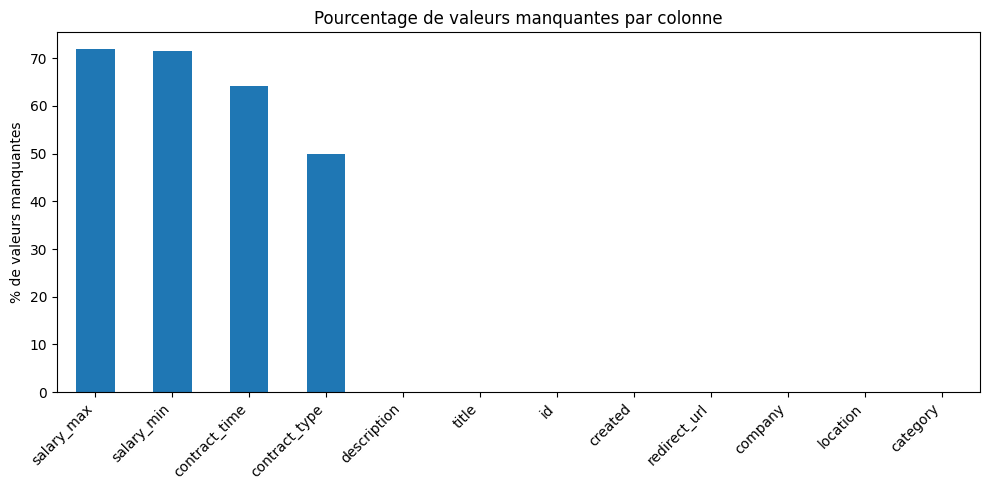

In [11]:

null_pct = df.isna().mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10,5))
null_pct.plot(kind='bar')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.ylabel('% de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Analyse des identifiants, URLs et source

In [12]:

report = {}

if 'job_id' in df.columns:
    report['job_id_is_unique'] = df['job_id'].nunique(dropna=True) == len(df)
    report['job_id_example'] = df['job_id'].dropna().astype(str).head(3).tolist()

if 'job_url' in df.columns:
    report['job_url_unique_count'] = int(df['job_url'].nunique(dropna=True))
    report['job_url_missing'] = int(df['job_url'].isna().sum())
    report['job_url_duplicates'] = int(df['job_url'].duplicated().sum())

if 'source_site' in df.columns:
    report['source_site_distribution'] = df['source_site'].value_counts(dropna=False).to_dict()

pd.DataFrame(list(report.items()), columns=['metric', 'value'])


,metric,value


## 5. Analyse des colonnes texte

In [13]:

text_columns = ['job_title', 'company_name', 'job_description', 'tags', 'location']
text_stats = []

for col in text_columns:
    if col in df.columns:
        s = df[col].fillna('').astype(str)
        text_stats.append({
            'column': col,
            'avg_length': round(s.str.len().mean(), 2),
            'median_length': round(s.str.len().median(), 2),
            'min_length': int(s.str.len().min()),
            'max_length': int(s.str.len().max()),
            'empty_like_count': int(s.str.strip().eq('').sum()),
        })

text_stats_df = pd.DataFrame(text_stats)
display(text_stats_df)


,column,avg_length,median_length,min_length,max_length,empty_like_count
0,location,153.67,156.0,94,228,0


In [15]:

# Détection de HTML, espaces inutiles, caractères spéciaux fréquents
text_quality = []
for col in ['job_title', 'company_name', 'job_description']:
    if col in df.columns:
        s = df[col].fillna('').astype(str)
        text_quality.append({
            'column': col,
            'contains_html_rows': int(s.str.contains(r'<[^>]+>', regex=True, na=False).sum()),
            'leading_or_trailing_spaces': int((s != s.str.strip()).sum()),
            'contains_newlines': int(s.str.contains(r'', regex=True, na=False).sum()),
            'contains_multiple_spaces': int(s.str.contains(r'\s{2,}', regex=True, na=False).sum()),
        })

display(pd.DataFrame(text_quality))


""


In [16]:

for col in ['job_title', 'company_name', 'job_description']:
    if col in df.columns:
        print(f"Exemples pour {col} ---")
        display(df[[col]].head(5))


## 6. Analyse des catégories et variables discrètes

In [17]:

for col in ['tags', 'contract_type', 'currency', 'remote', 'source_site']:
    if col in df.columns:
        print(f"Distribution de {col}")
        display(df[col].value_counts(dropna=False).head(15).rename_axis(col).reset_index(name='count'))


Distribution de contract_type


,contract_type,count
0,NaN,250
1,permanent,161
2,contract,89


In [18]:

if 'tags' in df.columns:
    plt.figure(figsize=(10,5))
    df['tags'].value_counts().head(10).plot(kind='bar')
    plt.title('Top 10 tags / catégories')
    plt.ylabel('Nombre d offres')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## 7. Analyse de la localisation

In [19]:

if 'location' in df.columns:
    location_df = pd.DataFrame({
        'location': df['location'],
        'has_leading_trailing_spaces': df['location'].fillna('').astype(str).ne(df['location'].fillna('').astype(str).str.strip()),
        'contains_comma': df['location'].fillna('').astype(str).str.contains(',', regex=False),
        'word_count': df['location'].fillna('').astype(str).str.split().str.len(),
        'char_length': df['location'].fillna('').astype(str).str.len(),
    })
    display(location_df.describe(include='all'))
    print("Top 15 locations:")
    display(df['location'].value_counts().head(15).rename_axis('location').reset_index(name='count'))


,location,has_leading_trailing_spaces,contains_comma,word_count,char_length
count,500,500,500,500.000000,500.000000
unique,161,1,1,NaN,NaN
top,"{'display_name': 'Paris, Ile-de-France', '__CLASS__': 'Adzuna::API::Response::Location', 'area': ['France', 'Ile-de-...",False,True,NaN,NaN
freq,87,500,500,NaN,NaN
mean,NaN,NaN,NaN,10.418000,153.668000
std,NaN,NaN,NaN,2.036559,24.987247
min,NaN,NaN,NaN,6.000000,94.000000
25%,NaN,NaN,NaN,9.000000,134.000000
50%,NaN,NaN,NaN,10.000000,156.000000
75%,NaN,NaN,NaN,11.000000,166.000000


Top 15 locations:


,location,count
0,"{'display_name': 'Paris, Ile-de-France', '__CLASS__': 'Adzuna::API::Response::Location', 'area': ['France', 'Ile-de-...",87
1,"{'area': ['France', 'Ile-de-France', 'Paris', '8ème Arrondissement'], 'display_name': '8ème Arrondissement, Paris', ...",37
2,"{'area': ['France'], '__CLASS__': 'Adzuna::API::Response::Location', 'display_name': 'France'}",33
3,"{'display_name': 'Lyon, Rhône', '__CLASS__': 'Adzuna::API::Response::Location', 'area': ['France', 'Auvergne-Rhône-A...",16
4,"{'area': ['France', 'Hauts-De-France', 'Nord', 'Lille'], 'display_name': 'Lille, Nord', '__CLASS__': 'Adzuna::API::R...",15
5,"{'__CLASS__': 'Adzuna::API::Response::Location', 'display_name': 'Toulouse, Haute-Garonne', 'area': ['France', 'Occi...",10
6,"{'__CLASS__': 'Adzuna::API::Response::Location', 'display_name': 'Rhône, Auvergne-Rhône-Alpes', 'area': ['France', '...",8
7,"{'area': ['France', 'Ile-de-France', 'Hauts-de-Seine'], 'display_name': 'Hauts-de-Seine, Ile-de-France', '__CLASS__'...",8
8,"{'display_name': 'Villeneuve-d'Ascq, Lille', 'area': ['France', 'Hauts-De-France', 'Nord', 'Lille', 'Villeneuve-d'As...",7
9,"{'display_name': 'Deux-Sèvres, Nouvelle-Aquitaine', 'area': ['France', 'Nouvelle-Aquitaine', 'Deux-Sèvres'], '__CLAS...",7


C:\Users\amina\AppData\Local\Temp\ipykernel_10596\2079806311.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


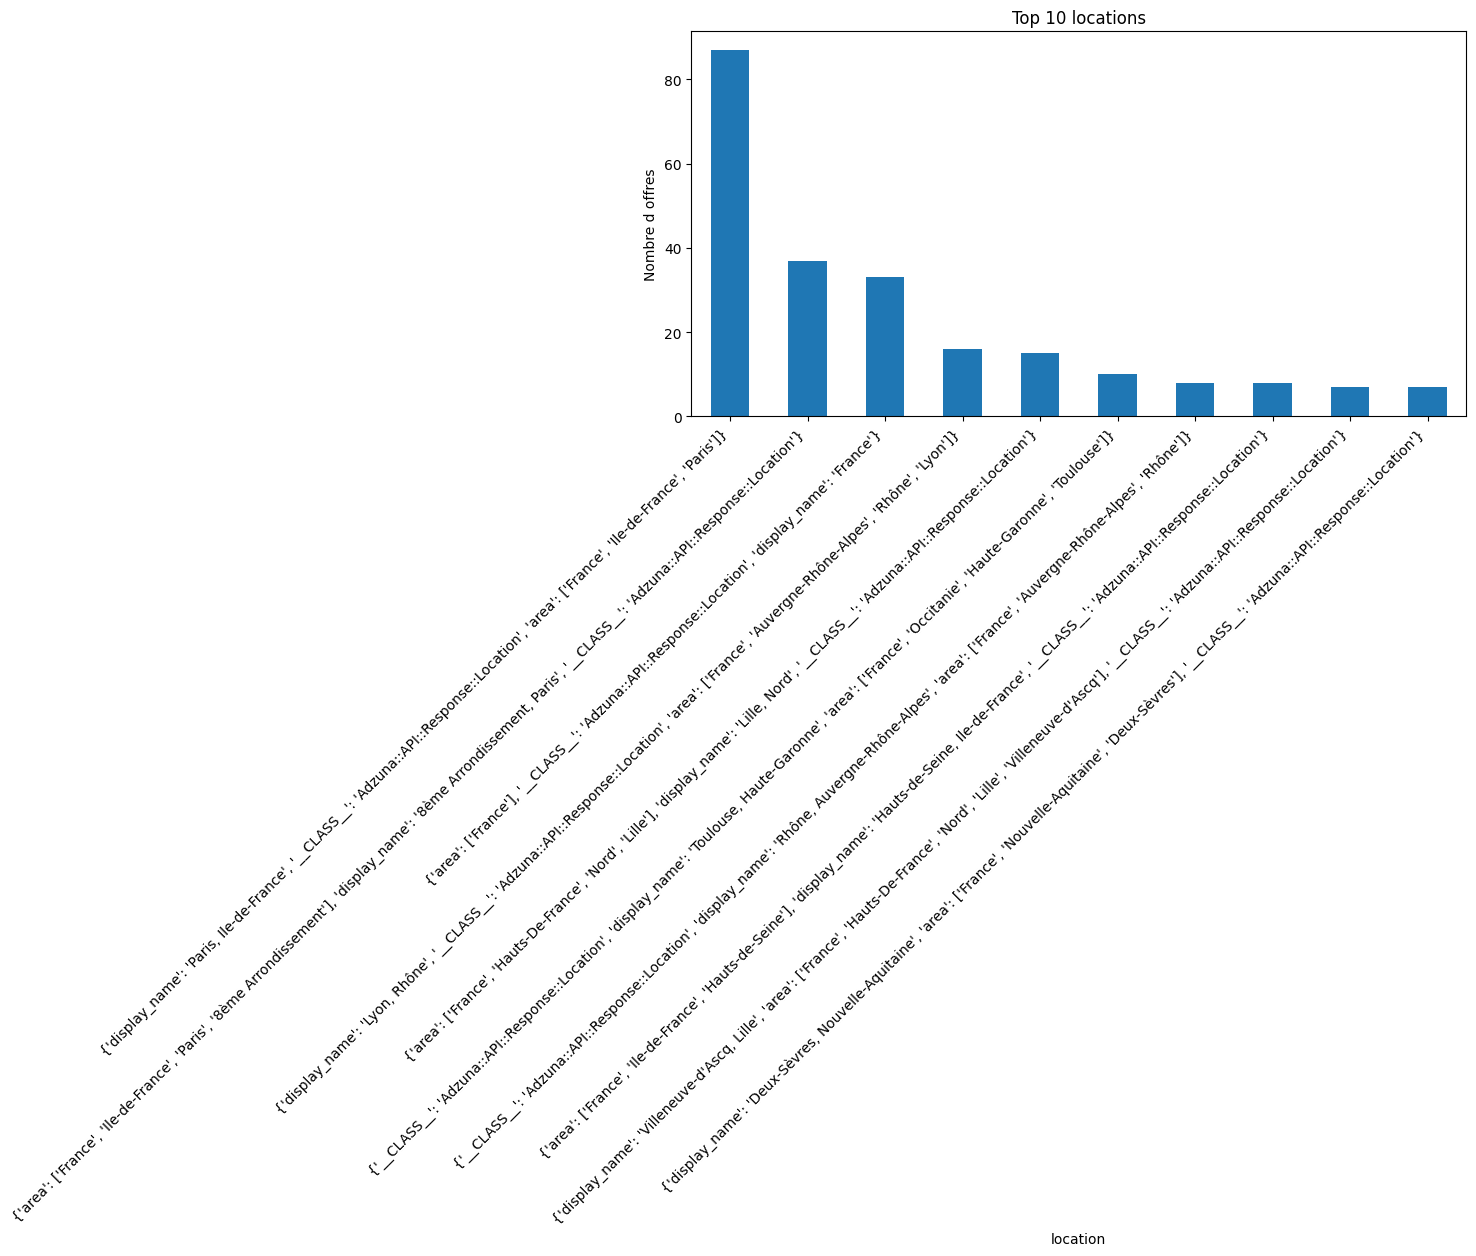

In [20]:

if 'location' in df.columns:
    plt.figure(figsize=(10,5))
    df['location'].value_counts().head(10).plot(kind='bar')
    plt.title('Top 10 locations')
    plt.ylabel('Nombre d offres')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## 8. Analyse des dates

In [21]:

for col in ['posted_date', 'expires_date']:
    if col in df.columns:
        df[f'{col}_parsed'] = pd.to_datetime(df[col], errors='coerce', utc=True)

_date_report = []
for col in ['posted_date', 'expires_date']:
    parsed = f'{col}_parsed'
    if parsed in df.columns:
        s = df[parsed]
        _date_report.append({
            'column': col,
            'valid_dates': int(s.notna().sum()),
            'invalid_dates': int(s.isna().sum()),
            'min_date': s.min(),
            'max_date': s.max(),
        })

display(pd.DataFrame(_date_report))


""


In [22]:

if 'posted_date_parsed' in df.columns and df['posted_date_parsed'].notna().any():
    posted_by_day = df['posted_date_parsed'].dt.date.value_counts().sort_index()
    plt.figure(figsize=(10,4))
    posted_by_day.plot(kind='line', marker='o')
    plt.title('Volume des offres par date de publication')
    plt.ylabel('Nombre d offres')
    plt.xlabel('Date')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## 9. Analyse des salaires

In [23]:

if 'salary_min' in df.columns and 'salary_max' in df.columns:
    df['salary_range'] = df['salary_max'] - df['salary_min']
    salary_summary = pd.DataFrame({
        'metric': ['salary_min non null', 'salary_max non null', 'both present', 'salary_min > salary_max', 'zero range'],
        'value': [
            int(df['salary_min'].notna().sum()),
            int(df['salary_max'].notna().sum()),
            int((df['salary_min'].notna() & df['salary_max'].notna()).sum()),
            int((df['salary_min'].fillna(-np.inf) > df['salary_max'].fillna(np.inf)).sum()),
            int((df['salary_range'] == 0).sum())
        ]
    })
    display(salary_summary)
    display(df[['salary_min', 'salary_max', 'salary_range']].describe())


,metric,value
0,salary_min non null,143
1,salary_max non null,141
2,both present,141
3,salary_min > salary_max,0
4,zero range,54


,salary_min,salary_max,salary_range
count,143.000000,141.000000,141.000000
mean,35416.629371,42605.794326,7225.808511
std,26742.251867,34723.589673,12511.345564
min,40.000000,44.000000,0.000000
25%,2125.000000,2900.000000,0.000000
50%,40000.000000,45000.000000,5000.000000
75%,50000.000000,60000.000000,10000.000000
max,125000.000000,192000.000000,84000.000000


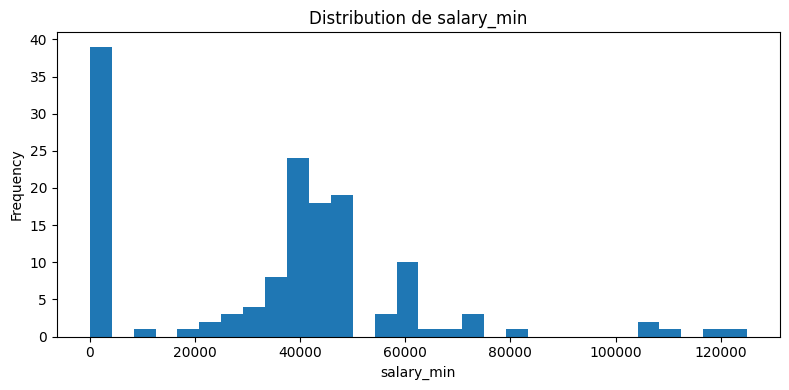

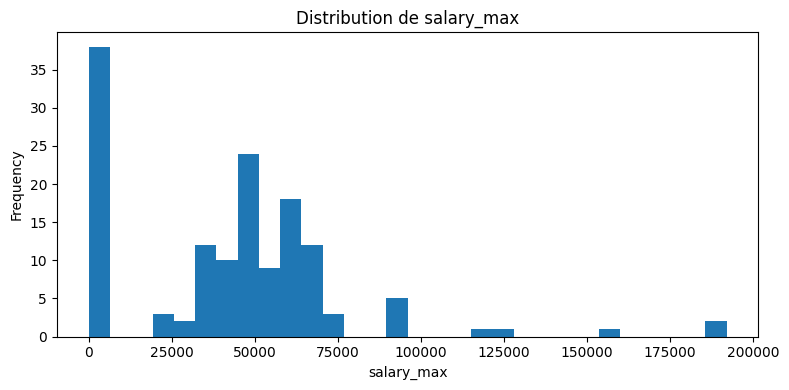

In [24]:

if 'salary_min' in df.columns and df['salary_min'].notna().any():
    plt.figure(figsize=(8,4))
    df['salary_min'].dropna().plot(kind='hist', bins=30)
    plt.title('Distribution de salary_min')
    plt.xlabel('salary_min')
    plt.tight_layout()
    plt.show()

if 'salary_max' in df.columns and df['salary_max'].notna().any():
    plt.figure(figsize=(8,4))
    df['salary_max'].dropna().plot(kind='hist', bins=30)
    plt.title('Distribution de salary_max')
    plt.xlabel('salary_max')
    plt.tight_layout()
    plt.show()


## 10. Relations utiles entre colonnes

In [25]:

if set(['tags', 'salary_min']).issubset(df.columns):
    by_tag_salary = df.groupby('tags', dropna=False).agg(
        offers=('job_id', 'count'),
        salary_min_available=('salary_min', lambda s: s.notna().sum()),
        avg_salary_min=('salary_min', 'mean'),
        avg_salary_max=('salary_max', 'mean') if 'salary_max' in df.columns else ('salary_min', 'mean')
    ).sort_values('offers', ascending=False)
    display(by_tag_salary.head(15))


In [26]:

if set(['contract_type', 'tags']).issubset(df.columns):
    cross = pd.crosstab(df['contract_type'].fillna('MISSING'), df['tags'].fillna('MISSING'))
    display(cross.iloc[:15, :10])


## 11. Conclusion automatique

In [27]:

insights = []

if 'salary_min' in df.columns:
    insights.append(f"- salary_min manquant dans {round(df['salary_min'].isna().mean()*100, 2)}% des lignes.")
if 'salary_max' in df.columns:
    insights.append(f"- salary_max manquant dans {round(df['salary_max'].isna().mean()*100, 2)}% des lignes.")
if 'expires_date' in df.columns:
    insights.append(f"- expires_date manquant dans {round(df['expires_date'].isna().mean()*100, 2)}% des lignes.")
if 'contract_type' in df.columns:
    insights.append(f"- contract_type manquant dans {round(df['contract_type'].isna().mean()*100, 2)}% des lignes.")
if 'tags' in df.columns and not df['tags'].dropna().empty:
    top_tag = df['tags'].value_counts().idxmax()
    top_tag_n = int(df['tags'].value_counts().max())
    insights.append(f"- La catégorie la plus fréquente est '{top_tag}' avec {top_tag_n} offres.")
if 'job_id' in df.columns:
    insights.append(f"- Doublons sur job_id : {int(df.duplicated(subset=['job_id']).sum())}.")
if 'posted_date_parsed' in df.columns and df['posted_date_parsed'].notna().any():
    insights.append(f"- Les dates de publication vont de {df['posted_date_parsed'].min()} à {df['posted_date_parsed'].max()}.")

print("Résumé des points importants :")
for x in insights:
    print(x)


Résumé des points importants :
- salary_min manquant dans 71.4% des lignes.
- salary_max manquant dans 71.8% des lignes.
- contract_type manquant dans 50.0% des lignes.



## 12. Recommandations de nettoyage

Après cette exploration, tu peux appliquer les actions suivantes :

1. **Convertir les dates** (`posted_date`, `expires_date`) en vrai format datetime.
2. **Conserver `job_id` comme clé technique** pour éviter les doublons.
3. **Traiter les colonnes très incomplètes** (`currency`, `remote`, `expires_date`) :
   - soit les supprimer du stockage final si elles sont toujours vides,
   - soit les garder mais avec documentation claire.
4. **Normaliser `location`** (trim, casse, séparation ville/région si nécessaire).
5. **Nettoyer `job_description`** si des retours ligne ou espaces multiples apparaissent.
6. **Analyser `tags`** car beaucoup de lignes semblent tomber dans `Unknown` : cela mérite peut-être une recatégorisation.
7. **Créer des colonnes dérivées** :
   - `salary_range`
   - `posted_day`
   - `posted_week`
   - `location_city`
   - `location_region`
